Componentes óptimos (95% varianza): 14
Varianza explicada: 95.68%


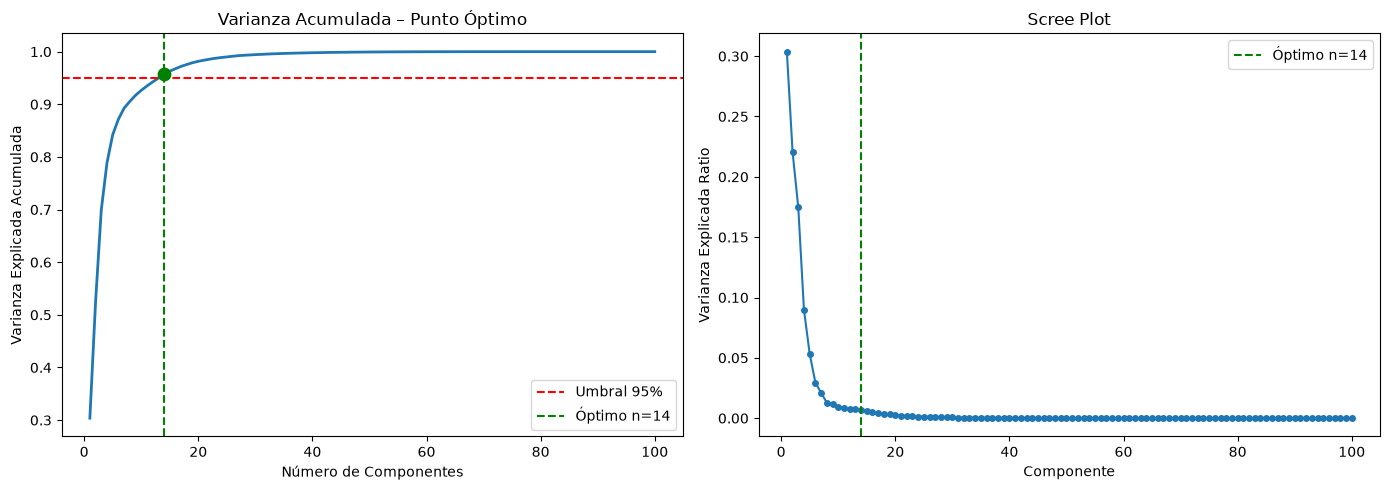


Forma reducida: (99933, 14)  (100 → 14 componentes)
Varianza total explicada: 95.68%


In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv('data/clothDataset_107.csv')

num_vertices = 25
num_features = 7  # x, y, z, sdf, vx, vy,vz

df = df.drop(columns=['frame'])

selected_columns = []
for i in range(num_vertices):
    selected_columns.extend([f'x{i}', f'y{i}', f'z{i}', 
                             f'vx{i}', f'vy{i}', f'vz{i}', 
                             f'sdf{i}'])
df = df[selected_columns]

# Escalar
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# ── Step 1: Detectar el número óptimo de componentes (umbral 95%) ──
pca_full = PCA()
pca_full.fit(df_scaled)

cumulative_variance = pca_full.explained_variance_ratio_.cumsum()
optimal_n = int(np.argmax(cumulative_variance >= 0.95)) + 1

print(f"Componentes óptimos (95% varianza): {optimal_n}")
print(f"Varianza explicada: {cumulative_variance[optimal_n - 1]:.2%}")

# ── Step 2: Gráfico de varianza acumulada con el punto óptimo marcado ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva acumulada
axes[0].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, linewidth=2)
axes[0].axhline(y=0.95, color='r', linestyle='--', label='Umbral 95%')
axes[0].axvline(x=optimal_n, color='g', linestyle='--', label=f'Óptimo n={optimal_n}')
axes[0].scatter([optimal_n], [cumulative_variance[optimal_n - 1]], color='g', zorder=5, s=80)
axes[0].set_xlabel('Número de Componentes')
axes[0].set_ylabel('Varianza Explicada Acumulada')
axes[0].set_title('Varianza Acumulada – Punto Óptimo')
axes[0].legend()

# Scree plot (varianza individual)
axes[1].plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
             pca_full.explained_variance_ratio_, 'o-', markersize=4)
axes[1].axvline(x=optimal_n, color='g', linestyle='--', label=f'Óptimo n={optimal_n}')
axes[1].set_xlabel('Componente')
axes[1].set_ylabel('Varianza Explicada Ratio')
axes[1].set_title('Scree Plot')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Step 3: Aplicar PCA con el número óptimo ──
pca = PCA(n_components=optimal_n)
df_pca = pca.fit_transform(df_scaled)

print(f"\nForma reducida: {df_pca.shape}  ({df_scaled.shape[1]} → {optimal_n} componentes)")
print(f"Varianza total explicada: {sum(pca.explained_variance_ratio_):.2%}")

In [ ]:
# Ver qué features dominan cada componente
# SOLO SI PCA CN 4 FEATURES
"""
import pandas as pd

feature_names = []
for i in range(6):
    feature_names.extend([f'x{i}', f'y{i}', f'z{i}', f'sdf{i}'])

components_df = pd.DataFrame(
    df_pca.components_,
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(optimal_n)]
)

print(components_df.round(3).to_string())
"""
a = 0

ValueError: Shape of passed values is (99933, 14), indices imply (14, 24)

Columnas totales usadas para PCA: 100
Componentes PCA óptimos (95% varianza): 13  [varianza explicada: 95.00%]


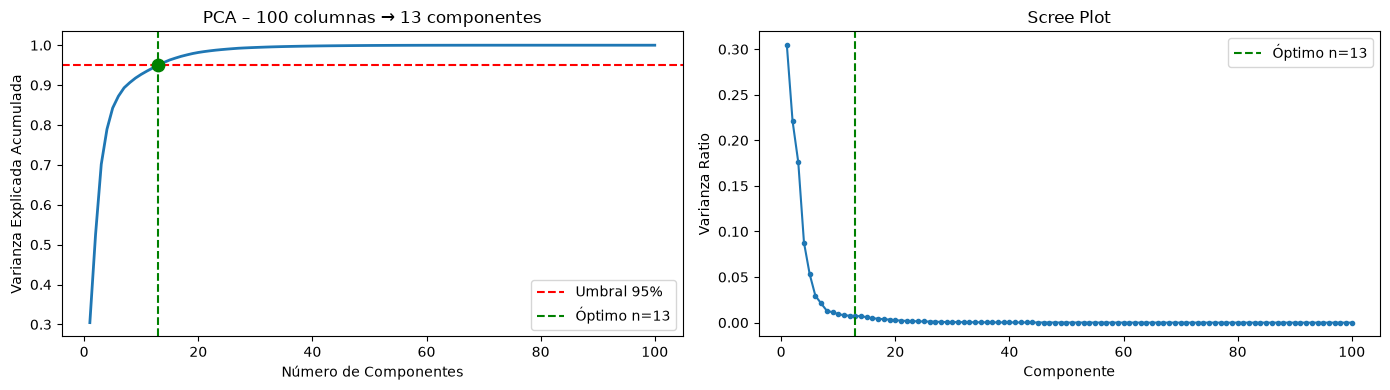

Forma train: (79946, 100) → (79946, 13)
Forma test:  (19987, 100)  → (19987, 13)
Tensor entrada PCA train: torch.Size([79946, 1, 13])
Tensor entrada PCA test:  torch.Size([19987, 1, 13])
Tensor XYZ train:         torch.Size([79946, 25, 3])
Tensor XYZ test:          torch.Size([19987, 25, 3])
SDF tensor train: torch.Size([79946, 25])
SDF tensor test:  torch.Size([19987, 25])


In [ ]:
#ADAPTAR DATAFRAME PARA EL RNN
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

num_frames   = df.shape[0]

data_flat_raw = df.values  # (N, num_vertices*13)
total_columns = data_flat_raw.shape[1]
print(f"Columnas totales usadas para PCA: {total_columns}")

# ── Split cronológico ANTES de ajustar scaler/PCA para evitar data leakage ──
train_size = int(0.8 * num_frames)
data_train_raw = data_flat_raw[:train_size]
data_test_raw  = data_flat_raw[train_size:]

# ── StandardScaler ajustado SOLO sobre train ──
input_scaler = StandardScaler()
data_train_scaled = input_scaler.fit_transform(data_train_raw)
data_test_scaled  = input_scaler.transform(data_test_raw)

# ── PCA ajustado SOLO sobre train ──
pca_search = PCA()
pca_search.fit(data_train_scaled)
cumvar = pca_search.explained_variance_ratio_.cumsum()
optimal_n = int(np.argmax(cumvar >= 0.95)) + 1
print(f"Componentes PCA óptimos (95% varianza): {optimal_n}  "
      f"[varianza explicada: {cumvar[optimal_n-1]:.2%}]")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(range(1, len(cumvar)+1), cumvar, linewidth=2)
axes[0].axhline(y=0.95, color='r', linestyle='--', label='Umbral 95%')
axes[0].axvline(x=optimal_n, color='g', linestyle='--', label=f'Óptimo n={optimal_n}')
axes[0].scatter([optimal_n], [cumvar[optimal_n-1]], color='g', zorder=5, s=80)
axes[0].set_xlabel('Número de Componentes')
axes[0].set_ylabel('Varianza Explicada Acumulada')
axes[0].set_title(f'PCA – {total_columns} columnas → {optimal_n} componentes')
axes[0].legend()
axes[1].plot(range(1, len(pca_search.explained_variance_ratio_)+1),
             pca_search.explained_variance_ratio_, 'o-', markersize=3)
axes[1].axvline(x=optimal_n, color='g', linestyle='--', label=f'Óptimo n={optimal_n}')
axes[1].set_xlabel('Componente')
axes[1].set_ylabel('Varianza Ratio')
axes[1].set_title('Scree Plot')
axes[1].legend()
plt.tight_layout()
plt.show()

# ── PCA definitivo ajustado sobre train, aplicado a ambos splits ──
input_pca = PCA(n_components=optimal_n)
data_train_pca = input_pca.fit_transform(data_train_scaled)  # (N_train, optimal_n)
data_test_pca  = input_pca.transform(data_test_scaled)       # (N_test,  optimal_n)

print(f"Forma train: {data_train_raw.shape} → {data_train_pca.shape}")
print(f"Forma test:  {data_test_raw.shape}  → {data_test_pca.shape}")

# ── Extraer XYZ real para calcular deltas target ──
xyz_cols = []
for i in range(num_vertices):
    xyz_cols.extend([f'x{i}', f'y{i}', f'z{i}'])
data_xyz = df[xyz_cols].values  # (N, num_vertices*3)
data_xyz_3d = data_xyz.reshape(num_frames, num_vertices, 3)
xyz_tensor = torch.tensor(data_xyz_3d, dtype=torch.float32)

# Splits XYZ alineados con splits PCA
xyz_train = xyz_tensor[:train_size]
xyz_test  = xyz_tensor[train_size:]

# ── Reshape PCA a 3D: (N, 1, optimal_n) ──
data_train_tensor = torch.tensor(data_train_pca.reshape(-1, 1, optimal_n), dtype=torch.float32)
data_test_tensor  = torch.tensor(data_test_pca.reshape(-1, 1, optimal_n),  dtype=torch.float32)

print(f"Tensor entrada PCA train: {data_train_tensor.shape}")
print(f"Tensor entrada PCA test:  {data_test_tensor.shape}")
print(f"Tensor XYZ train:         {xyz_train.shape}")
print(f"Tensor XYZ test:          {xyz_test.shape}")

# ── Extraer SDF real por vértice para el fix del rollout ──────────────────────
# Necesario para reconstruir el frame PCA con SDF real en lugar de aproximado
sdf_cols = [f'sdf{i}' for i in range(num_vertices)]
data_sdf = df[sdf_cols].values                            # (N, num_vertices)
data_sdf_tensor = torch.tensor(data_sdf, dtype=torch.float32)
sdf_train = data_sdf_tensor[:train_size]
sdf_test  = data_sdf_tensor[train_size:]
print(f"SDF tensor train: {sdf_train.shape}")
print(f"SDF tensor test:  {sdf_test.shape}")


In [ ]:
class ClothSequenceDataset(Dataset):
    def __init__(self, pca_frames, xyz_frames, sdf_frames, seq_len=5):
        """
        pca_frames : Tensor [N, 1, n_components]  — entrada comprimida
        xyz_frames : Tensor [N, V, 3]             — posiciones XYZ reales
        sdf_frames : Tensor [N, V]                — SDF real por vértice
        seq_len    : frames históricos que usa la RNN
        """
        self.pca_frames = pca_frames if isinstance(pca_frames, torch.Tensor) \
                           else torch.tensor(pca_frames, dtype=torch.float32)
        self.xyz_frames = xyz_frames if isinstance(xyz_frames, torch.Tensor) \
                           else torch.tensor(xyz_frames, dtype=torch.float32)
        self.sdf_frames = sdf_frames if isinstance(sdf_frames, torch.Tensor) \
                           else torch.tensor(sdf_frames, dtype=torch.float32)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.pca_frames) - 2 * self.seq_len + 1

    def __getitem__(self, idx):
        seq_pca     = self.pca_frames[idx : idx + self.seq_len]
        future_start = idx + self.seq_len - 1
        future_end   = future_start + self.seq_len + 1
        future_xyz   = self.xyz_frames[future_start : future_end]
        # FIX 1: devolver SDF real de los frames futuros para usarlo en el rollout
        future_sdf   = self.sdf_frames[future_start : future_end]
        return seq_pca, future_xyz, future_sdf


seq_length = 16
batch_size = 32
ROLLOUT_STEPS = 24

train_dataset = ClothSequenceDataset(data_train_tensor, xyz_train, sdf_train, seq_len=seq_length)
test_dataset  = ClothSequenceDataset(data_test_tensor,  xyz_test,  sdf_test,  seq_len=seq_length)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

for batch_seq, batch_future_xyz, batch_future_sdf in train_loader:
    print(f"Entrada RNN (PCA):    {batch_seq.shape}")         # [B, seq_len, 1, optimal_n]
    print(f"XYZ futuros:          {batch_future_xyz.shape}")  # [B, seq_len+1, V, 3]
    print(f"SDF futuros:          {batch_future_sdf.shape}")  # [B, seq_len+1, V]
    break


Entrada RNN (PCA):    torch.Size([32, 16, 1, 13])
XYZ futuros:          torch.Size([32, 17, 25, 3])
SDF futuros:          torch.Size([32, 17, 25])


In [ ]:
import torch.nn as nn

class FlatLSTMClothUnityPCA(nn.Module):
    def __init__(self, n_pca_components, num_vertices, hidden_size, num_outputs=3):
        """
        n_pca_components : número de componentes PCA (entrada comprimida por frame)
        num_vertices     : vértices del tejido (para reconstruir la salida)
        hidden_size      : tamaño del estado oculto
        num_outputs      : coordenadas a predecir por vértice (3 → delta XYZ)
        """
        super().__init__()
        self.num_vertices = num_vertices
        self.num_outputs  = num_outputs
        self.input_size   = n_pca_components

        # FIX 4: nn.LSTM fusionado en lugar de RNNCell con relu.
        # - Evita el problema de dying neurons de relu en RNNs.
        # - Es el único operador recurrente soportado por Unity Inference Engine.
        # - Se lee output[:, -1, :] en lugar de h_n para evitar el bug del
        #   importador ONNX de Sentis con salidas secundarias.
        self.lstm = nn.LSTM(
            input_size=self.input_size,
            hidden_size=hidden_size,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, num_vertices * num_outputs)

    def forward(self, x):
        # x: [Batch, Seq_Len, 1, n_pca_components]
        batch_size = x.size(0)
        seq_len    = x.size(1)
        x_flat = x.view(batch_size, seq_len, -1)   # [B, T, n_pca]

        output, _ = self.lstm(x_flat)               # output: [B, T, hidden]
        h_t = output[:, -1, :]                       # [B, hidden] — último paso

        pred_flat  = self.fc(h_t)
        pred_delta = pred_flat.view(batch_size, self.num_vertices, self.num_outputs)
        return pred_delta   # [B, V, 3] — delta XYZ


In [ ]:
import torch
import json
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando device: {device}")

# ==============================================================================
# 1. COMPUTE TARGET STATS (solo sobre train)
# ==============================================================================
all_target_deltas = []
for batch_seq, batch_future_xyz, batch_future_sdf in train_loader:
    for k in range(batch_future_xyz.shape[1] - 1):
        delta = batch_future_xyz[:, k+1, :, :] - batch_future_xyz[:, k, :, :]
        all_target_deltas.append(delta.reshape(-1, 3))

full_target_tensor = torch.cat(all_target_deltas, dim=0)
target_mean = full_target_tensor.mean(dim=0).to(device)
target_std  = full_target_tensor.std(dim=0).to(device)
print("target_mean:", target_mean)
print("target_std: ", target_std)

# ==============================================================================
# 2. PRE-COMPUTAR TENSORES PCA / SCALER EN DEVICE
#    Evita hacer numpy + detach dentro del rollout (FIX 2)
# ==============================================================================
raw_feature_size = num_vertices * num_features   # p.ej. 25 * 4 = 100

scaler_mean_t = torch.tensor(input_scaler.mean_,    dtype=torch.float32, device=device)
scaler_std_t  = torch.tensor(input_scaler.scale_,   dtype=torch.float32, device=device)
pca_mean_t    = torch.tensor(input_pca.mean_,        dtype=torch.float32, device=device)
pca_comp_t    = torch.tensor(input_pca.components_,  dtype=torch.float32, device=device)  # [optimal_n, raw_size]

# ==============================================================================
# 3. GUARDAR NORM PARAMS EN JSON
# ==============================================================================
norm_data = {
    "input_scaler_mean": input_scaler.mean_.tolist(),
    "input_scaler_std":  input_scaler.scale_.tolist(),
    "pca_components":    input_pca.components_.flatten().tolist(),
    "pca_mean":          input_pca.mean_.tolist(),
    "target_mean":       target_mean.cpu().tolist(),
    "target_std":        target_std.cpu().tolist(),
    "optimal_n":         optimal_n,
    "num_vertices":      num_vertices,
}
with open("PCAre2000.json", "w") as f:
    json.dump(norm_data, f)
print("Parámetros guardados en PCAre2000.json")

# ==============================================================================
# 4. SETUP MODELO + EARLY STOPPING
# ==============================================================================
model     = FlatLSTMClothUnityPCA(n_pca_components=optimal_n, num_vertices=num_vertices,
                                   hidden_size=128, num_outputs=3)
model     = model.to(device)
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)

# ── Early stopping ─────────────────────────────────────────────────────────
PATIENCE          = 30
MIN_DELTA         = 1e-6
best_test_loss    = float('inf')
epochs_no_improve = 0
best_model_state  = None
# ──────────────────────────────────────────────────────────────────────────

total_params = sum(p.numel() for p in model.parameters())
print(f"Modelo creado | input_size={optimal_n} | output={num_vertices*3}")
print(f"Parámetros totales: {total_params:,}")
print(f"PCA components shape: {input_pca.components_.shape}")


Usando device: cuda


c:\Users\Eva\miniconda3\envs\dl2024\Lib\site-packages\torch\cuda\__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5060 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90 sm_37 compute_37.
If you want to use the NVIDIA GeForce RTX 5060 Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


target_mean: tensor([-1.2842e-06,  2.2256e-07,  6.0803e-09], device='cuda:0')
target_std:  tensor([0.0140, 0.0036, 0.0016], device='cuda:0')
Parámetros guardados en PCAre2000.json
Modelo creado | input_size=13 | output=75
Parámetros totales: 82,891
PCA components shape: (13, 100)


In [ ]:
# ==============================================================================
# FIXES APLICADOS EN ESTE NOTEBOOK RESPECTO A rnn02_PCA_refix:
#
# FIX 1 — SDF real en el rollout:
#   El nuevo frame PCA se construye con el SDF real del dataset (batch_future_sdf),
#   no con el SDF aproximado que devuelve input_pca.inverse_transform().
#   Esto elimina el gap entre entrenamiento e inferencia (en Unity el SDF
#   siempre es el valor real calculado desde la posición de la bola).
#
# FIX 2 — Sin numpy/detach dentro del rollout:
#   La proyección PCA se hace íntegramente en PyTorch (con pca_comp_t y
#   pca_mean_t precalculados en device), manteniendo el grafo de gradientes
#   intacto a través de pred_xyz hacia el nuevo frame PCA.
#
# FIX 3 — Delta relativo a la posición predicha (no la real):
#   prev_pred_xyz se actualiza con pred_xyz en cada paso. El modelo aprende
#   a predecir el delta desde su propia posición anterior, igual que ocurre
#   en Unity donde el delta se aplica sobre los vértices predichos del frame
#   anterior.
#
# FIX 4 — LSTM en lugar de RNNCell con relu:
#   Ver celda 4.
# ==============================================================================

EPOCHS      = 50
NOISE_SIGMA = 0.03
VEL_WEIGHT  = 1.0


def run_rollout(batch_seq_pca, batch_future_xyz, batch_future_sdf, add_noise=False):
    """
    batch_seq_pca:    [B, seq_len, 1, optimal_n]
    batch_future_xyz: [B, W+1, V, 3]   índice 0 = frame actual, 1..W = targets
    batch_future_sdf: [B, W+1, V]      SDF real de cada frame futuro
    """
    B = batch_seq_pca.shape[0]
    W = batch_future_xyz.shape[1] - 1

    window_pca = batch_seq_pca.clone()

    if add_noise:
        window_pca = window_pca + torch.randn_like(window_pca) * NOISE_SIGMA

    total_loss = torch.tensor(0.0, device=device)

    # FIX 3: base inicial = posición real del frame t=0
    prev_pred_xyz = batch_future_xyz[:, 0, :, :].to(device)

    for step in range(W):
        # ── Forward ────────────────────────────────────────────────
        pred_delta_norm = model(window_pca)                          # [B, V, 3]

        # Desnormalizar y aplicar sobre posición predicha anterior
        pred_delta_real = pred_delta_norm * target_std + target_mean
        pred_xyz = prev_pred_xyz + pred_delta_real                   # [B, V, 3]

        real_xyz_next = batch_future_xyz[:, step+1, :, :].to(device)

        # ── Loss posición ──────────────────────────────────────────
        # FIX 3: delta relativo a prev_pred_xyz (posición predicha), no a la real
        real_delta      = real_xyz_next - prev_pred_xyz
        real_delta_norm = (real_delta - target_mean) / target_std
        loss_pos = criterion(pred_delta_norm, real_delta_norm)

        # ── Loss velocidad ─────────────────────────────────────────
        real_prev_xyz = batch_future_xyz[:, step, :, :].to(device)
        pred_vel = pred_xyz - prev_pred_xyz
        real_vel = real_xyz_next - real_prev_xyz
        loss_vel = criterion(
            pred_vel / target_std.clamp(min=1e-8),
            real_vel / target_std.clamp(min=1e-8)
        )

        total_loss = total_loss + loss_pos + VEL_WEIGHT * loss_vel

        # ── FIX 1+2: nuevo frame PCA con pred_xyz + SDF real ───────
        # Todo en PyTorch, sin numpy ni detach — grafo de gradientes intacto
        sdf_step = batch_future_sdf[:, step+1, :].to(device)        # [B, V] SDF real

        raw_new = torch.zeros(B, raw_feature_size, device=device)
        for v in range(num_vertices):
            base = v * num_features
            raw_new[:, base:base+3] = pred_xyz[:, v, :]             # xyz predicho
            raw_new[:, base+3]      = sdf_step[:, v]                 # SDF real

        # StandardScaler → centrar con pca_mean → proyectar
        scaled_new   = (raw_new - scaler_mean_t) / scaler_std_t
        centered_new = scaled_new - pca_mean_t
        new_pca_vec  = centered_new @ pca_comp_t.T                   # [B, optimal_n]
        new_frame    = new_pca_vec.unsqueeze(1).unsqueeze(1)         # [B, 1, 1, optimal_n]

        # Deslizar ventana
        window_pca    = torch.cat([window_pca[:, 1:, :, :], new_frame], dim=1)
        prev_pred_xyz = pred_xyz

    return total_loss / W


# ==============================================================================
# BUCLE DE ENTRENAMIENTO
# ==============================================================================
history = {'train': [], 'test': [], 'vertex_error': []}

for epoch in range(1, EPOCHS + 1):

    # ── TRAIN ────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for batch_seq, batch_future_xyz, batch_future_sdf in train_loader:
        batch_seq        = batch_seq.float().to(device)
        batch_future_xyz = batch_future_xyz.float().to(device)
        batch_future_sdf = batch_future_sdf.float().to(device)

        loss = run_rollout(batch_seq, batch_future_xyz, batch_future_sdf, add_noise=True)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    scheduler.step()
    avg_train = train_loss / len(train_loader)

    # ── TEST ─────────────────────────────────────────────────────
    model.eval()
    test_loss   = 0.0
    total_err   = 0.0
    total_verts = 0
    all_pred_pos   = []
    all_target_pos = []

    with torch.no_grad():
        for batch_seq, batch_future_xyz, batch_future_sdf in test_loader:
            batch_seq        = batch_seq.float().to(device)
            batch_future_xyz = batch_future_xyz.float().to(device)
            batch_future_sdf = batch_future_sdf.float().to(device)

            loss = run_rollout(batch_seq, batch_future_xyz, batch_future_sdf, add_noise=False)
            test_loss += loss.item()

            pred_dn    = model(batch_seq)
            last_xyz   = batch_future_xyz[:, 0, :, :]
            pred_pos   = last_xyz + pred_dn * target_std + target_mean
            target_pos = batch_future_xyz[:, 1, :, :]

            all_pred_pos.append(pred_pos.cpu().numpy())
            all_target_pos.append(target_pos.cpu().numpy())

            distances    = torch.norm(pred_pos - target_pos, dim=-1)
            total_err   += distances.sum().item()
            total_verts += distances.numel()

    avg_test     = test_loss / len(test_loader)
    avg_vert_err = total_err / total_verts

    history['train'].append(avg_train)
    history['test'].append(avg_test)
    history['vertex_error'].append(avg_vert_err)

    preds_pos_np   = np.concatenate(all_pred_pos,   axis=0)
    targets_pos_np = np.concatenate(all_target_pos, axis=0)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train: {avg_train:.6f} | "
              f"Test: {avg_test:.6f} | VertErr: {avg_vert_err:.6f} | "
              f"Best: {best_test_loss:.6f} | Patience: {epochs_no_improve}/{PATIENCE}")

    # ── Early stopping ────────────────────────────────────────────
    if avg_test < best_test_loss - MIN_DELTA:
        best_test_loss    = avg_test
        epochs_no_improve = 0
        best_model_state  = {key: v.cpu().clone() for key, v in model.state_dict().items()}
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping en epoch {epoch} — sin mejora en {PATIENCE} épocas.")
            print(f"Mejor test loss: {best_test_loss:.6f}")
            break

# Restaurar mejor modelo
if best_model_state is not None:
    model.load_state_dict({key: v.to(device) for key, v in best_model_state.items()})
    print("Modelo restaurado al mejor checkpoint.")

print("\nEntrenamiento completado.")


Epoch 001 | Train: 2.064334 | Test: 1.766067 | VertErr: 0.004053 | Best: inf | Patience: 0/30
Epoch 010 | Train: 0.990314 | Test: 1.147531 | VertErr: 0.002743 | Best: 1.176566 | Patience: 0/30
Epoch 020 | Train: 0.814723 | Test: 1.011167 | VertErr: 0.002536 | Best: 1.011490 | Patience: 0/30
Epoch 030 | Train: 0.739334 | Test: 0.966114 | VertErr: 0.002471 | Best: 0.972260 | Patience: 0/30
Epoch 040 | Train: 0.692956 | Test: 0.944958 | VertErr: 0.002439 | Best: 0.948260 | Patience: 2/30
Epoch 050 | Train: 0.659806 | Test: 0.931915 | VertErr: 0.002418 | Best: 0.932836 | Patience: 2/30
Modelo restaurado al mejor checkpoint.

Entrenamiento completado.


In [ ]:
"""
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# 1. Combinar los batches recogidos en arrays únicos
preds_np   = np.concatenate(all_pred_deltas,  axis=0)  # (Total_Frames, Vertices, 3)
targets_np = np.concatenate(all_target_deltas, axis=0) # (Total_Frames, Vertices, 3)

# 2. Reshape a 2D: (Total_Frames, Vertices * 3)
preds_2d   = preds_np.reshape(preds_np.shape[0], -1)
targets_2d = targets_np.reshape(targets_np.shape[0], -1)

# ── Detectar número óptimo de componentes sobre los targets ──
pca_full = PCA()
pca_full.fit(targets_2d)
cumvar = pca_full.explained_variance_ratio_.cumsum()
optimal_n_eval = int(np.argmax(cumvar >= 0.95)) + 1
optimal_n_eval = min(optimal_n_eval, targets_2d.shape[1])  # no puede superar las features

print(f"Componentes óptimos para visualización post-entrenamiento: {optimal_n_eval}")
print(f"Varianza explicada (targets): {cumvar[optimal_n_eval - 1]:.2%}")

# ── Gráfico de varianza para la evaluación ──
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar) + 1), cumvar, linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='Umbral 95%')
plt.axvline(x=optimal_n_eval, color='g', linestyle='--', label=f'Óptimo n={optimal_n_eval}')
plt.scatter([optimal_n_eval], [cumvar[optimal_n_eval - 1]], color='g', zorder=5, s=80)
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('PCA Evaluación – Varianza de los Targets')
plt.legend()
plt.tight_layout()
plt.show()

# ── Ajustar PCA sobre targets (espacio compartido) y transformar ambos ──
pca_eval = PCA(n_components=optimal_n_eval)
pca_eval.fit(targets_2d)
pca_targets = pca_eval.transform(targets_2d)
pca_preds   = pca_eval.transform(preds_2d)

# ── Visualización: siempre 2D con PC1 vs PC2 ──
plt.figure(figsize=(10, 8))
plt.scatter(pca_targets[:, 0], pca_targets[:, 1],
            alpha=0.5, label='Ground Truth (Targets)', color='blue', s=10)
plt.scatter(pca_preds[:, 0],   pca_preds[:, 1],
            alpha=0.5, label='Predicciones del Modelo', color='red',  s=10)
plt.title(f'PCA Cloth Dynamics – Ground Truth vs Predicciones\n'
          f'(usando {optimal_n_eval} componentes óptimos, mostrando PC1 vs PC2)')
plt.xlabel(f'PC1 ({pca_eval.explained_variance_ratio_[0]:.2%} var)')
plt.ylabel(f'PC2 ({pca_eval.explained_variance_ratio_[1]:.2%} var)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Si hay 3+ componentes, añadir vista 3D ──
if optimal_n_eval >= 3:
    from mpl_toolkits.mplot3d import Axes3D
    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(pca_targets[:, 0], pca_targets[:, 1], pca_targets[:, 2],
               alpha=0.4, label='Ground Truth', color='blue', s=8)
    ax.scatter(pca_preds[:, 0],   pca_preds[:, 1],   pca_preds[:, 2],
               alpha=0.4, label='Predicciones',  color='red',  s=8)
    ax.set_title(f'PCA 3D – PC1 vs PC2 vs PC3  (n_optimal={optimal_n_eval})')
    ax.set_xlabel(f'PC1 ({pca_eval.explained_variance_ratio_[0]:.2%})')
    ax.set_ylabel(f'PC2 ({pca_eval.explained_variance_ratio_[1]:.2%})')
    ax.set_zlabel(f'PC3 ({pca_eval.explained_variance_ratio_[2]:.2%})')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print("Vista 3D generada (PC1, PC2, PC3)")
else:
    print("Solo 2 componentes óptimos – se muestra únicamente la vista 2D.")
    """

'\nfrom sklearn.decomposition import PCA\nimport numpy as np\nimport matplotlib.pyplot as plt\n\n# 1. Combinar los batches recogidos en arrays únicos\npreds_np   = np.concatenate(all_pred_deltas,  axis=0)  # (Total_Frames, Vertices, 3)\ntargets_np = np.concatenate(all_target_deltas, axis=0) # (Total_Frames, Vertices, 3)\n\n# 2. Reshape a 2D: (Total_Frames, Vertices * 3)\npreds_2d   = preds_np.reshape(preds_np.shape[0], -1)\ntargets_2d = targets_np.reshape(targets_np.shape[0], -1)\n\n# ── Detectar número óptimo de componentes sobre los targets ──\npca_full = PCA()\npca_full.fit(targets_2d)\ncumvar = pca_full.explained_variance_ratio_.cumsum()\noptimal_n_eval = int(np.argmax(cumvar >= 0.95)) + 1\noptimal_n_eval = min(optimal_n_eval, targets_2d.shape[1])  # no puede superar las features\n\nprint(f"Componentes óptimos para visualización post-entrenamiento: {optimal_n_eval}")\nprint(f"Varianza explicada (targets): {cumvar[optimal_n_eval - 1]:.2%}")\n\n# ── Gráfico de varianza para la evalua

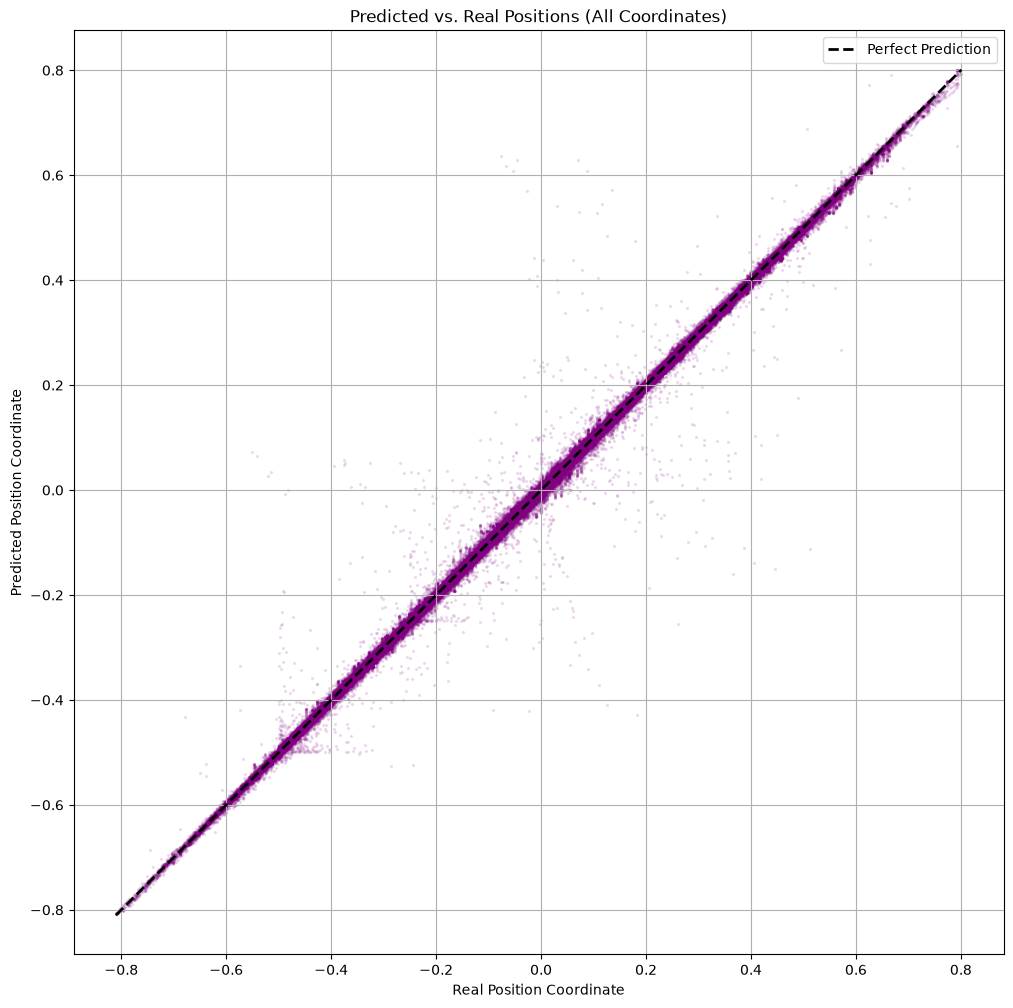

In [ ]:
import matplotlib.pyplot as plt

# Flatten the arrays so we just have a massive list of X, Y, and Z coordinates
true_flat = targets_pos_np.reshape(-1)
pred_flat = preds_pos_np.reshape(-1)

plt.figure(figsize=(12, 12))
plt.scatter(true_flat, pred_flat, alpha=0.1, color='purple', s=2)

# Draw the perfect prediction line (y = x)
min_val = min(true_flat.min(), pred_flat.min())
max_val = max(true_flat.max(), pred_flat.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Predicted vs. Real Positions (All Coordinates)')
plt.xlabel('Real Position Coordinate')
plt.ylabel('Predicted Position Coordinate')
plt.legend()
plt.grid(True)
plt.axis('equal') # Keeps the aspect ratio square
plt.show()

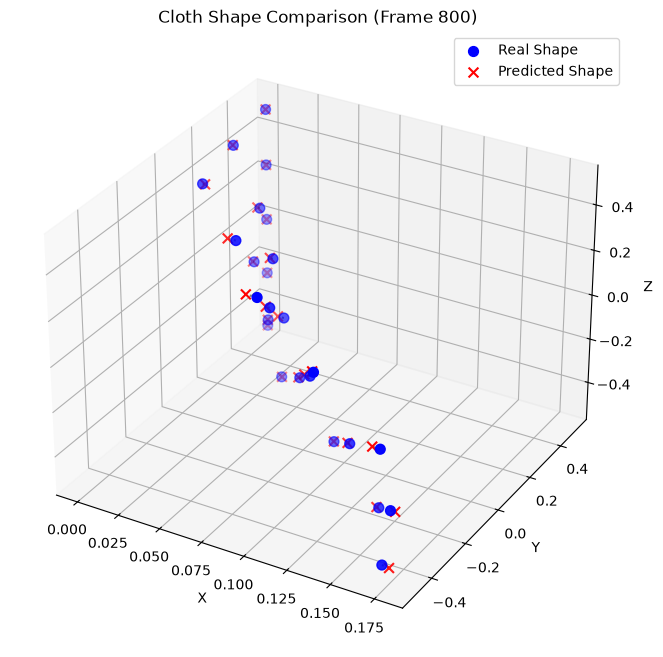

In [ ]:
# Choose a random frame from your test set to visualize
frame_idx = 800 # Change this to look at different moments
num_vertices = targets_pos_np.shape[1]

real_frame = targets_pos_np[frame_idx] # Shape: (Vertices, 3)
pred_frame = preds_pos_np[frame_idx]   # Shape: (Vertices, 3)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Extract X, Y, Z for Real positions
rx, ry, rz = real_frame[:, 0], real_frame[:, 1], real_frame[:, 2]
# Extract X, Y, Z for Predicted positions
px, py, pz = pred_frame[:, 0], pred_frame[:, 1], pred_frame[:, 2]

# Plot the real cloth vertices in Blue
ax.scatter(rx, ry, rz, c='blue', label='Real Shape', s=50, marker='o')

# Plot the predicted cloth vertices in Red
ax.scatter(px, py, pz, c='red', label='Predicted Shape', s=50, marker='x')

# Draw lines connecting the predicted vertex to the real vertex to show the error
for i in range(num_vertices):
    ax.plot([rx[i], px[i]], [ry[i], py[i]], [rz[i], pz[i]], color='gray', linestyle='dotted')

ax.set_title(f'Cloth Shape Comparison (Frame {frame_idx})')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

In [ ]:
import torch
import onnx
import onnxruntime

model.eval()
model_cpu = model.cpu()

dummy_input = torch.randn(1, seq_length, 1, optimal_n)

onnx_program = torch.onnx.export(
    model_cpu,
    dummy_input,
    "PCAre2000.onnx",
    export_params=True,
    opset_version=15,
    input_names=['input'],
    output_names=['output'],
)
print("Exportado a ONNX: PCAre2000.onnx")

onnx_model = onnx.load("PCAre2000.onnx")
onnx.checker.check_model(onnx_model)

ort_session = onnxruntime.InferenceSession("PCAre2000.onnx")
ort_out = ort_session.run(None, {'input': dummy_input.numpy()})
print(f"ONNX output shape: {ort_out[0].shape}")
print("Export exitoso — compatible con Unity Inference Engine (Sentis).")
print(f"Input shape: {dummy_input.shape}")

# Restaurar modelo en device original
model = model_cpu.to(device)


Exportado a ONNX: PCAre2000.onnx
ONNX output shape: (1, 25, 3)
Export exitoso — compatible con Unity Inference Engine (Sentis).
Input shape: torch.Size([1, 16, 1, 13])


c:\Users\Eva\miniconda3\envs\dl2024\Lib\site-packages\torch\onnx\symbolic_opset9.py:4279: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with LSTM can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the model. 
  warnings.warn(
